In [31]:
import matplotlib.pyplot as plt
import numpy as np
from synthetic_data import distributions, generate_ground_truths, generate_sample_csv

In [32]:
def owens_bozic_model(y, t, params):
    T, E, C, M = y
    a, b, dE, dC, g, jE, jC, K, k, l, mE, mC, qE, qC, s, KT, KE, KC, gamma = params

    C = max(C, 0)
    E = max(E, 0)

    tol = 1e-10

    if T < tol:
        DE = 0
    elif E < T:
        DE = dE * (E / T)**l / (s + (E / T)**l) * T
    else:
        DE = dE * (1 - s / (s + (T/E)**(-l))) * T

    if T < tol:
        DC = 0
    elif C < T:
        DC = dC * (C / T)**l / (s + (C / T)**l) * T
    else:
        DC = dC * (1 - s / (s + (T/C)**(-l))) * T

    dT_dt = a * T * (1 - b * T) - DE - DC - KT * (1 - np.exp(-M)) * T
    dE_dt = g - mE * E - jE * np.log((E + C) / K) * (DE**2) / (k + DE**2) * E  - qE * E * T - KE * (1 - np.exp(-M)) * E
    dC_dt = - mC * C - jC * np.log((E + C) / K) * (DC**2) / (k + DC**2) * C - qC * C * T - KC * (1 - np.exp(-M)) * C
    dM_dt = - gamma * M

    return [dT_dt, dE_dt, dC_dt, dM_dt]

In [33]:
def csv_and_indiv_param_vals(
    param: str,
    noise_level: float,
    n_obs: int,
    param_seed: int,
    noise_seed: int,
    csv_filename: str | None = None,
    n_indivs=10,
    max_day_number=100,
):
    f_pop = 1.0     # scale factor for pop param std

    partial_pop_param_info = [
        ("a", 3.3e-1, 0.6 * f_pop, distributions["lognormal"]),
        ("b", 2.26e-11, 5.1 * f_pop, distributions["lognormal"]),
        ("dE", 3.17, 0.6 * f_pop, distributions["lognormal"]),
        ("dC", 2.25, 0.01 * f_pop, distributions["lognormal"]),
        ("g", 1.03e4, 1.7 * f_pop, distributions["lognormal"]),
        ("jE", 1.56e-2, 0.75 * f_pop, distributions["lognormal"]),
        ("jC", 3.46e-1, 0.75 * f_pop, distributions["lognormal"]),
        ("K", 5.21e8, 1.5 * f_pop, distributions["lognormal"]),
        ("k", 8.67e6, 3.0 * f_pop, distributions["lognormal"]),
        ("l", 1.418, 0.013 * f_pop, distributions["lognormal"]),
        ("mE", 1.76e-2, 0.76 * f_pop, distributions["lognormal"]),
        ("mC", 0.293, 0.01 * f_pop, distributions["lognormal"]),
        ("qE", 1.28e-10, 1.35 * f_pop, distributions["lognormal"]),
        ("qC", 2.14e-10, 2.6 * f_pop, distributions["lognormal"]),
        ("s", 3.02e-1, 0.17 * f_pop, distributions["lognormal"]),
        ("KT", 0.7, 0.01 * f_pop, distributions["lognormal"]),
        ("KE", 0.6, 0.01 * f_pop, distributions["lognormal"]),
        ("KC", 0.6, 0.01 * f_pop, distributions["lognormal"]),
        ("gamma", 0.9, 0.01 * f_pop, distributions["lognormal"]),
    ]

    param_idx = -1
    for i, x in enumerate(partial_pop_param_info):
        if x[0] == param:
            param_idx = i
            break

    if param_idx == -1:
        raise ValueError(f"unknown param {param}")
    
    pop_param_info = [(*x, x[0] != param) for x in partial_pop_param_info]
    obs_var_info = [
        ("T", 1.58e9, 1.5, distributions["normal"], "combined1", 0, noise_level, 1, distributions["normal"], "log10", True),
        ("E", 4e5, 0.01, distributions["normal"], "combined1", 0, noise_level, 1, distributions["normal"], "log10", True),
        ("C", 6.3e7, 2.0, distributions["normal"], "combined1", 0, noise_level, 1, distributions["normal"], "log10", True),
        ("M", 6.0, 0.2, distributions["normal"], "combined1", 0, noise_level, 1, distributions["normal"], "log10", True),
    ]
    obs_times_all = [[max_day_number * i // n_obs for i in range(1, n_obs + 1)] for _ in range(n_indivs)]
    sampled_params_all, initial_conditions_all, _, _, _ = generate_sample_csv(
        csv_filename or "owens_bozic_noiseexp",
        owens_bozic_model,
        pop_param_info,
        obs_var_info,
        n_indivs,
        n_obs,
        max_day_number,
        obs_times_all=obs_times_all,
        param_seed=param_seed,
        noise_seed=noise_seed,
    )

    return [x[param_idx] for x in sampled_params_all], sampled_params_all, initial_conditions_all, param_idx

In [34]:
def get_pred_params(param: str):
    """
    Get a list of the predicted values of `param` for each patient
    """
    fp = "./owens_bozic/IndividualParameters/simulatedIndividualParameters.txt"
    with open(fp, "r") as f:
        cols = f.readline().split(",")
        col_idx = cols.index(param)
        pred_params = []

        curr_indiv_preds = []
        while True:
            line = f.readline()
            vals = line.split(",")
            if not line or int(vals[0]) == 1 and curr_indiv_preds:
                pred_params.append(np.median(curr_indiv_preds))
                curr_indiv_preds = []
            if not line:
                break
            curr_indiv_preds.append(float(vals[col_idx]))

    return pred_params


def get_pred_params_all(
    pred_params: list[float], true_params_all: list[list[float]], param_idx: int
):
    pred_params_all = [[x for x in true_params] for true_params in true_params_all]
    for params, pred_param in zip(pred_params_all, pred_params):
        params[param_idx] = pred_param

    return pred_params_all


n_indivs = 10
obs_times_all = [list(range(5, 101, 5)) for _ in range(n_indivs)]


def compute_rms(
    true_params_all: list[list[float]],
    pred_params_all: list[list[float]],
    initial_conditions_all: list[list[float]],
    model=owens_bozic_model,
    obs_times_all=obs_times_all,
):
    true_ground_truths = generate_ground_truths(
        model, true_params_all, initial_conditions_all, obs_times_all
    )
    pred_ground_truths = generate_ground_truths(
        model, pred_params_all, initial_conditions_all, obs_times_all
    )
    rms_all = []
    for true_ground_truth, pred_ground_truth in zip(
        true_ground_truths, pred_ground_truths
    ):
        squared_diffs = (pred_ground_truth - true_ground_truth) ** 2
        rms = np.sqrt(np.mean(squared_diffs, axis=1))
        rms_all.append(rms)
    avg_rms_all = np.mean(rms_all, axis=0)
    return avg_rms_all

In [56]:
from itertools import product

combos = list(product((20, 10, 5), (0.1, 0.25, 0.5)))
idx = 8

param = "l"
n_pts, noise_level = combos[idx]
print(n_pts, noise_level)
true_indiv_params, sampled_params_all, initial_conditions_all, param_idx = (
    csv_and_indiv_param_vals(param, noise_level, n_pts, param_seed=1, noise_seed=1 + idx)
)

5 0.5


In [55]:
# run after running monolix
pred_params = get_pred_params(param)

avg_abs_err = np.mean(np.abs(np.array(pred_params) - np.array(true_indiv_params)))
avg_rel_err = np.mean(
    np.abs(np.array(pred_params) - np.array(true_indiv_params))
    / np.array(true_indiv_params)
)
print(np.array(true_indiv_params))
print(np.array(pred_params) - np.array(true_indiv_params))
print(f"{param=}, {noise_level=}, {n_pts=}: {avg_abs_err:.6f}, {100 * avg_rel_err:.6f}%")

pred_params_all = get_pred_params_all(pred_params, sampled_params_all, param_idx)
compute_rms(sampled_params_all, pred_params_all, initial_conditions_all)

[1.42046076 1.42199165 1.41718426 1.36667687 1.43091924 1.42114336
 1.41719824 1.45535261 1.44479631 1.3656031 ]
[ 0.01157424  0.00446835  0.00245574 -0.06996687 -0.03337924  0.02297164
  0.00166176  0.01237239 -0.05634131 -0.0024031 ]
param='l', noise_level=0.25, n_pts=5: 0.021759, 1.541392%


array([1.61155416e+07, 2.38855730e+03, 4.83072013e+06, 6.68892524e-10])

1.4561


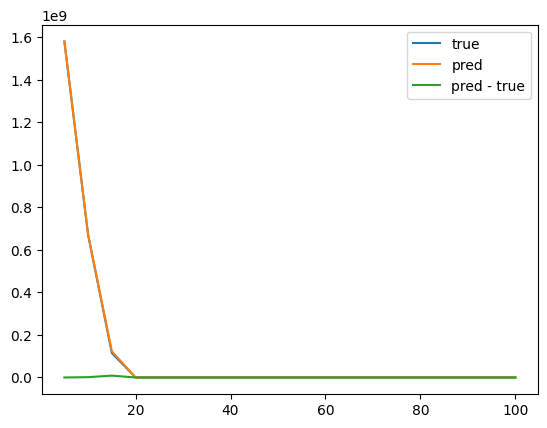

In [44]:
idx = 7
print(pred_params[idx])
gt_true_T = generate_ground_truths(
    owens_bozic_model,
    sampled_params_all[idx:idx + 1],
    initial_conditions_all[idx:idx + 1],
    obs_times_all[idx:idx + 1],
)[0][0]
gt_pred_T = generate_ground_truths(
    owens_bozic_model,
    pred_params_all[idx:idx + 1],
    initial_conditions_all[idx:idx + 1],
    obs_times_all[idx:idx + 1],
)[0][0]
plt.plot(obs_times_all[0], gt_true_T, label="true")
plt.plot(obs_times_all[0], gt_pred_T, label="pred")
plt.plot(obs_times_all[0], gt_pred_T - gt_true_T, label="pred - true")
plt.legend()